In [9]:
import glob
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# FASE 1: CARGA Y PREPARACIÓN DE DATOS
# ==========================================
print("--- FASE 1: CARGA DE DATOS ---")

# 1.1 Comprobación de hardware
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Hardware detectado: {device}")

# 1.2 Cargar datos
files = glob.glob("*.parquet")
df = pd.concat([pd.read_parquet(file) for file in files], ignore_index=True)
print(f"Filas cargadas: {len(df):,}")

# 1.3 Limpiar las etiquetas (Tácticas MITRE)
# Asumimos que la columna se llama 'label_tactic'. Cambia el nombre si es distinto.
columna_etiqueta = 'label_tactic' 
textos_benignos = ['none', 'None', 'NONE', '-', 'N/A', '', None]
df['mitre_clean'] = df[columna_etiqueta].fillna('Normal').replace(textos_benignos, 'Normal')

# 1.4 Convertir las Tácticas a números enteros (0, 1, 2...)
encoder_mitre = LabelEncoder()
y_multi_np = encoder_mitre.fit_transform(df['mitre_clean'])
y_multi = torch.tensor(y_multi_np, dtype=torch.long) # PyTorch exige tipo Long para multiclase
num_clases = len(encoder_mitre.classes_)

print(f"\nTotal de clases (Tácticas) detectadas: {num_clases}")
for i, clase in enumerate(encoder_mitre.classes_):
    print(f" - [{i}] {clase}: {len(df[df['mitre_clean'] == clase]):,} registros")

--- FASE 1: CARGA DE DATOS ---
Hardware detectado: cuda
Filas cargadas: 1,916,757

Total de clases (Tácticas) detectadas: 8
 - [0] Credential Access: 871,188 registros
 - [1] Defense Evasion: 6,048 registros
 - [2] Exfiltration: 559 registros
 - [3] Initial Access: 10,662 registros
 - [4] Normal: 958,109 registros
 - [5] Persistence: 6,048 registros
 - [6] Privilege Escalation: 6,048 registros
 - [7] Reconnaissance: 58,095 registros


In [10]:

# ==========================================
# FASE 2: CONSTRUCCIÓN DEL GRAFO (PyTorch Geometric)
# ==========================================
print("\n--- FASE 2: CREANDO EL GRAFO ---")

# 2.1 Mapear IPs (origen y destino) a IDs numéricos para los nodos
encoder_ips = LabelEncoder()
todas_las_ips = pd.concat([df['src_ip_zeek'], df['dest_ip_zeek']]).unique()
encoder_ips.fit(todas_las_ips)

src_nodos = encoder_ips.transform(df['src_ip_zeek'])
dst_nodos = encoder_ips.transform(df['dest_ip_zeek'])

# Matriz de topología (quién se conecta con quién)
edge_index = torch.tensor(np.vstack((src_nodos, dst_nodos)), dtype=torch.long)

# 2.2 Características de las conexiones (Features)
# Selecciona las columnas numéricas que tengas. Rellenamos NaNs con 0.
columnas_features = ['orig_bytes', 'resp_bytes', 'orig_pkts', 'resp_pkts', 'duration']
features_conexion = df[columnas_features].fillna(0).values
edge_attr = torch.tensor(features_conexion, dtype=torch.float)

# 2.3 Características de los Nodos (IPs)
# Como no tenemos propiedades intrínsecas de las IPs, creamos una matriz de "unos"
num_nodos = len(todas_las_ips)
x = torch.ones((num_nodos, 1), dtype=torch.float)

# 2.4 Ensamblar el grafo y enviarlo a la RTX 5090
grafo_pyg = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y_multi).to(device)

# 2.5 Separar en Entrenamiento (80%) y Test (20%)
num_edges = grafo_pyg.num_edges
indices = torch.randperm(num_edges)
train_size = int(0.8 * num_edges)

grafo_pyg.train_mask = torch.zeros(num_edges, dtype=torch.bool)
grafo_pyg.train_mask[indices[:train_size]] = True

grafo_pyg.test_mask = torch.zeros(num_edges, dtype=torch.bool)
grafo_pyg.test_mask[indices[train_size:]] = True

print(f"Grafo ensamblado y enviado a VRAM: Nodos={grafo_pyg.num_nodes}, Conexiones={grafo_pyg.num_edges}")


--- FASE 2: CREANDO EL GRAFO ---
Grafo ensamblado y enviado a VRAM: Nodos=357, Conexiones=1916757


In [11]:
# ==========================================
# FASE 3: DEFINICIÓN DE LA RED NEURONAL
# ==========================================
print("\n--- FASE 3: ARQUITECTURA DEL MODELO ---")

class DetectorMitreMulticlase(nn.Module):
    def __init__(self, node_in_dim, edge_in_dim, hidden_dim, num_classes):
        super().__init__()
        # GraphSAGE para extraer el vecindario de la IP
        self.conv1 = SAGEConv(node_in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)
        
        # Red Lineal para clasificar la conexión
        clf_in_dim = (hidden_dim * 2) + edge_in_dim
        self.clf = nn.Sequential(
            nn.Linear(clf_in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_classes) # Salen N probabilidades
        )
        
    def forward(self, node_x, edge_idx, edge_features):
        h = self.conv1(node_x, edge_idx).relu()
        h = self.conv2(h, edge_idx).relu()
        
        src, dst = edge_idx[0], edge_idx[1]
        representacion_conexion = torch.cat([h[src], h[dst], edge_features], dim=-1)
        
        return self.clf(representacion_conexion)

# Instanciamos
modelo = DetectorMitreMulticlase(
    node_in_dim=1, edge_in_dim=len(columnas_features), hidden_dim=64, num_classes=num_clases
).to(device)


--- FASE 3: ARQUITECTURA DEL MODELO ---


In [12]:
from sklearn.utils.class_weight import compute_class_weight

# ==========================================
# FASE 4: ENTRENAMIENTO (CON PESOS BALANCEADOS)
# ==========================================
print("\n--- FASE 4: ENTRENAMIENTO (MODO ANTI-DESBALANCEO) ---")

# 4.1 Calculamos cuánto "pesa" cada clase según su rareza
pesos_clases = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_multi_np),
    y=y_multi_np
)

# Convertimos a tensor de PyTorch y lo mandamos a la GPU
pesos_tensor = torch.tensor(pesos_clases, dtype=torch.float).to(device)

print("Penalizaciones asignadas a la IA por fallar:")
for i, clase in enumerate(encoder_mitre.classes_):
    print(f" - {clase}: x{pesos_clases[i]:.2f} de castigo")

# 4.2 Inyectamos los pesos en la función de pérdida
criterion = nn.CrossEntropyLoss(weight=pesos_tensor)
optimizer = torch.optim.Adam(modelo.parameters(), lr=0.005)
epocas = 100

for epoch in range(1, epocas + 1):
    modelo.train()
    optimizer.zero_grad()
    
    out = modelo(grafo_pyg.x, grafo_pyg.edge_index, grafo_pyg.edge_attr)
    
    loss = criterion(out[grafo_pyg.train_mask], grafo_pyg.y[grafo_pyg.train_mask])
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        modelo.eval()
        with torch.no_grad():
            predicciones = out[grafo_pyg.test_mask].argmax(dim=1)
            reales = grafo_pyg.y[grafo_pyg.test_mask]
            acc = (predicciones == reales).sum().item() / reales.size(0)
            
            # Calculamos también el Macro F1 rápido para ver si aprende
            from sklearn.metrics import f1_score
            macro_f1 = f1_score(reales.cpu(), predicciones.cpu(), average='macro', zero_division=0)
            
        print(f"Época {epoch:03d}/{epocas} | Loss: {loss:.4f} | Accuracy: {acc:.4f} | Macro F1: {macro_f1:.4f}")


--- FASE 4: ENTRENAMIENTO (MODO ANTI-DESBALANCEO) ---
Penalizaciones asignadas a la IA por fallar:
 - Credential Access: x0.28 de castigo
 - Defense Evasion: x39.62 de castigo
 - Exfiltration: x428.61 de castigo
 - Initial Access: x22.47 de castigo
 - Normal: x0.25 de castigo
 - Persistence: x39.62 de castigo
 - Privilege Escalation: x39.62 de castigo
 - Reconnaissance: x4.12 de castigo
Época 010/100 | Loss: 21.4437 | Accuracy: 0.6206 | Macro F1: 0.2233
Época 020/100 | Loss: 10.8746 | Accuracy: 0.8168 | Macro F1: 0.2829
Época 030/100 | Loss: 5.6178 | Accuracy: 0.8578 | Macro F1: 0.3164
Época 040/100 | Loss: 2.6958 | Accuracy: 0.9092 | Macro F1: 0.3493
Época 050/100 | Loss: 1.5616 | Accuracy: 0.8973 | Macro F1: 0.3466
Época 060/100 | Loss: 1.3576 | Accuracy: 0.8820 | Macro F1: 0.3411
Época 070/100 | Loss: 1.2580 | Accuracy: 0.9027 | Macro F1: 0.3514
Época 080/100 | Loss: 1.2441 | Accuracy: 0.9167 | Macro F1: 0.3556
Época 090/100 | Loss: 1.2126 | Accuracy: 0.9246 | Macro F1: 0.3740
Époc


--- FASE 5: EVALUACIÓN DETALLADA ---
                      precision    recall  f1-score   support

   Credential Access       1.00      0.99      0.99    173908
     Defense Evasion       0.10      0.79      0.18      1202
        Exfiltration       0.05      0.81      0.09       131
      Initial Access       0.43      0.44      0.43      2066
              Normal       1.00      0.96      0.98    192244
         Persistence       0.18      0.00      0.00      1163
Privilege Escalation       0.00      0.00      0.00      1247
      Reconnaissance       0.44      0.52      0.48     11391

            accuracy                           0.95    383352
           macro avg       0.40      0.56      0.39    383352
        weighted avg       0.97      0.95      0.96    383352

¡Modelo guardado como 'detector_mitre_multiclase.pt'!


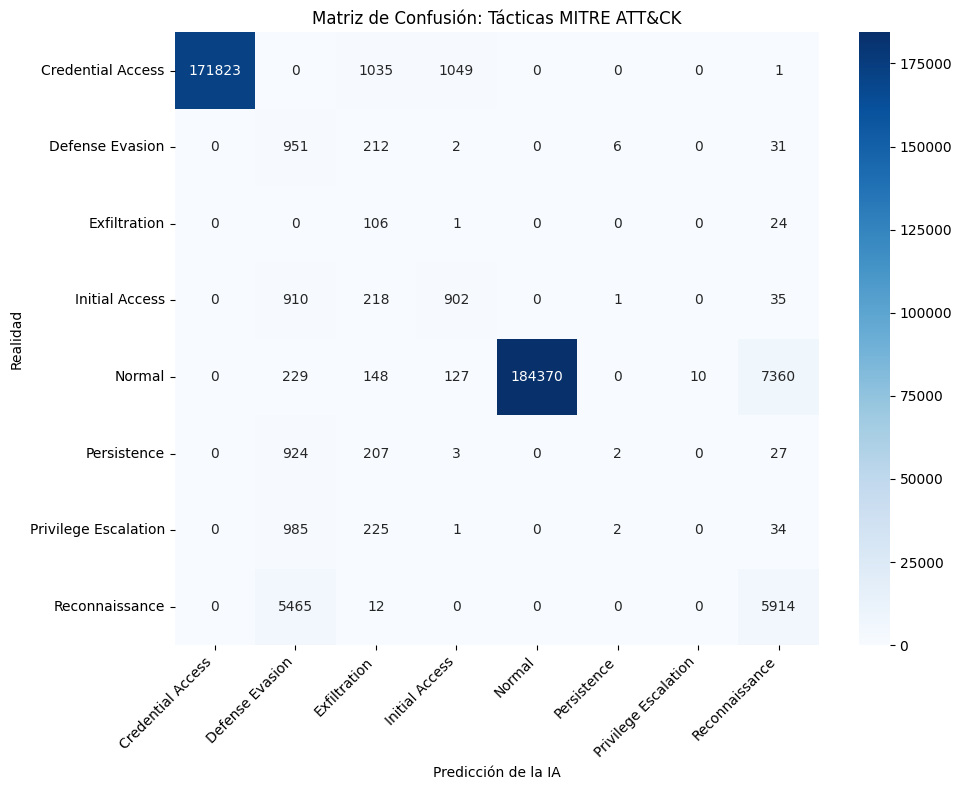

In [13]:

# ==========================================
# FASE 5: EVALUACIÓN Y GUARDADO
# ==========================================
print("\n--- FASE 5: EVALUACIÓN DETALLADA ---")

modelo.eval()
with torch.no_grad():
    out_final = modelo(grafo_pyg.x, grafo_pyg.edge_index, grafo_pyg.edge_attr)
    pred_final = out_final[grafo_pyg.test_mask].argmax(dim=1).cpu().numpy()
    reales_final = grafo_pyg.y[grafo_pyg.test_mask].cpu().numpy()

print(classification_report(reales_final, pred_final, target_names=encoder_mitre.classes_, zero_division=0))

# Guardamos el cerebro
torch.save(modelo.state_dict(), 'detector_mitre_multiclase.pt')
print("¡Modelo guardado como 'detector_mitre_multiclase.pt'!")

# Dibujamos la Matriz de Confusión (Opcional, pero genial para el TFM)
plt.figure(figsize=(10,8))
cm = confusion_matrix(reales_final, pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=encoder_mitre.classes_, yticklabels=encoder_mitre.classes_)
plt.title('Matriz de Confusión: Tácticas MITRE ATT&CK')
plt.xlabel('Predicción de la IA')
plt.ylabel('Realidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()